In [47]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

For entropy with split of 0.25 we got  78.26%  
For entropy with split of 0.20 we got  74.54%  
For entropy with split of 0.30 we got  78.78%

For gini with split of 0.25 we got  83.33%  
For gini with split of 0.20 we got  80.00%  
For gini with split of 0.30 we got  75.75% 

In [48]:
dataset = pd.read_csv('../DATA/bestsellers.csv')

x = dataset.iloc[ : , 2:6]
y = dataset.iloc[ : , -1]

In [49]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [50]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [51]:
from sklearn.tree import DecisionTreeClassifier
#classifier = DecisionTreeClassifier(criterion='entropy', random_state=0)
classifier = DecisionTreeClassifier(criterion='gini', random_state=0)
classifier.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [52]:
y_pred = classifier.predict(x_test)

In [53]:
from sklearn import metrics
accuracy = metrics.accuracy_score(y_test, y_pred )
print("accuracy", accuracy*100, "%")

accuracy 80.0 %


In [54]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Fiction       0.79      0.76      0.78        50
 Non Fiction       0.81      0.83      0.82        60

    accuracy                           0.80       110
   macro avg       0.80      0.80      0.80       110
weighted avg       0.80      0.80      0.80       110



In [55]:
new_individual = np.array([[5,17350,8,2018]])
new_individual_scaled = sc.transform(new_individual)
new_predection = classifier.predict(new_individual_scaled)

c:\Users\bda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Text(0.6797304258241759, 0.9642857142857143, 'x[0] <= 0.58\ngini = 0.491\nsamples = 440\nvalue = [190.0, 250.0]'),
 Text(0.537345467032967, 0.8928571428571429, 'x[1] <= 1.216\ngini = 0.437\nsamples = 294\nvalue = [95.0, 199.0]'),
 Text(0.6085379464285714, 0.9285714285714286, 'True  '),
 Text(0.4373282967032967, 0.8214285714285714, 'x[2] <= 0.27\ngini = 0.397\nsamples = 271\nvalue = [74, 197]'),
 Text(0.2867445054945055, 0.75, 'x[3] <= 0.13\ngini = 0.451\nsamples = 195\nvalue = [67, 128]'),
 Text(0.12293956043956043, 0.6785714285714286, 'x[1] <= -0.727\ngini = 0.495\nsamples = 111\nvalue = [50.0, 61.0]'),
 Text(0.06043956043956044, 0.6071428571428571, 'x[3] <= -0.185\ngini = 0.331\nsamples = 43\nvalue = [9, 34]'),
 Text(0.04945054945054945, 0.5357142857142857, 'x[0] <= -2.099\ngini = 0.283\nsamples = 41\nvalue = [7.0, 34.0]'),
 Text(0.02197802197802198, 0.4642857142857143, 'x[3] <= -1.13\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.01098901098901099, 0.39285714285714285, 'gini

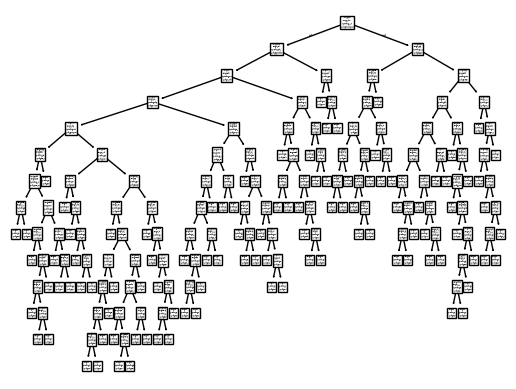

In [56]:
from sklearn import tree
tree.plot_tree(classifier)